 # CS480: Introduction to Quantum Computing

 ## Homework 2: Single-Qubit States

 **Due:** Sunday 11:59 PM

 **Total Points:** 100 (+ 10 bonus)



 ### Instructions

 - Complete all exercises in this notebook

 - Run all cells to verify your answers

 - For visualization questions, include the output images

 - Submit the completed .ipynb file to Canvas



 ### This homework covers:

 - Part 1: Dirac Notation (25 pts)

 - Part 2: Tensor Products (20 pts)

 - Part 3: Bloch Sphere States (25 pts)

 - Part 4: Gates as Rotations (30 pts)

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt


 ---

 ## Part 1: Dirac Notation (25 points)

 ### Exercise 1.1 (5 points)

 Define the basis states using Dirac notation understanding.

 Create $|0\rangle$, $|1\rangle$, $|+\rangle$, $|-\rangle$ as numpy arrays.

In [3]:
ket_0 = np.array([1, 0], dtype=complex)
ket_1 = np.array([0, 1], dtype=complex)
ket_plus = (ket_0 + ket_1) / np.sqrt(2)   # TODO: (|0⟩ + |1⟩)/√2
ket_minus = (ket_0 - ket_1) / np.sqrt(2) # TODO: (|0⟩ - |1⟩)/√2

print("|+⟩ =", ket_plus)
print("|-⟩ =", ket_minus)


|+⟩ = [0.70710678+0.j 0.70710678+0.j]
|-⟩ = [ 0.70710678+0.j -0.70710678+0.j]


 ### Exercise 1.2 (5 points)

 Compute inner products using $\langle a|b\rangle = a^\dagger \cdot b$

 Remember: $\langle a|$ is the conjugate transpose (bra) of $|a\rangle$

In [4]:
def inner_product(bra_state, ket_state):
    """Compute ⟨bra|ket⟩."""
    return np.vdot(bra_state, ket_state)  # vdot handles conjugation

# Calculate these inner products:
inner_0_1 = inner_product(ket_0, ket_1)       # TODO: ⟨0|1⟩ (should be 0)
inner_plus_minus = inner_product(ket_plus, ket_minus) # TODO: ⟨+|-⟩ (should be 0)
inner_0_plus = inner_product(ket_0, ket_plus)    # TODO: ⟨0|+⟩

print(f"⟨0|1⟩ = {inner_0_1}")
print(f"⟨+|-⟩ = {inner_plus_minus}")
print(f"⟨0|+⟩ = {inner_0_plus}")


⟨0|1⟩ = 0j
⟨+|-⟩ = (-2.2371143170757382e-17+0j)
⟨0|+⟩ = (0.7071067811865475+0j)


 ### Exercise 1.3 (5 points)

 Outer products: $|a\rangle\langle b|$ creates a matrix

 $|a\rangle\langle b| = a \cdot b^\dagger$

In [5]:
def outer_product(ket_a, ket_b):
    """Compute |a⟩⟨b| = a ⊗ b†."""
    return np.outer(ket_a, np.conj(ket_b))

# The projector onto |0⟩ is P_0 = |0⟩⟨0|
P_0 = outer_product(ket_0, ket_0)
print(f"P_0 = |0⟩⟨0| =\n{P_0}")

# TODO: Create P_1 = |1⟩⟨1| (projector onto |1⟩)
# TODO: Create P_plus = |+⟩⟨+| (projector onto |+⟩)
# TODO: Verify P_0 + P_1 = I (identity matrix)

P_1 = outer_product(ket_1, ket_1)   # TODO
P_plus = outer_product(ket_plus, ket_plus) # TODO

print(f"P_1 =\n{P_1}")
print(f"P_+ =\n{P_plus}")
print(f"P_0 + P_1 =\n{P_0 + P_1 if P_1 is not None else 'incomplete'}")


P_0 = |0⟩⟨0| =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
P_1 =
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
P_+ =
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]
P_0 + P_1 =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


 ### Exercise 1.4 (5 points)

 Express states in different bases.

 $|0\rangle$ in the $\{|+\rangle, |-\rangle\}$ basis: $|0\rangle = \langle+|0\rangle|+\rangle + \langle-|0\rangle|-\rangle$

In [6]:
# Calculate the coefficients for |0⟩ in {|+⟩,|-⟩} basis
coeff_plus = inner_product(ket_plus, ket_0)   # TODO: ⟨+|0⟩
coeff_minus = inner_product(ket_minus, ket_0)  # TODO: ⟨-|0⟩

print(f"|0⟩ = {coeff_plus}|+⟩ + {coeff_minus}|-⟩")

# TODO: Verify by reconstructing |0⟩ from these coefficients
reconstructed_0 = coeff_plus * ket_plus + coeff_minus * ket_minus  # TODO: coeff_plus * ket_plus + coeff_minus * ket_minus
print(f"Reconstructed |0⟩ = {reconstructed_0}")


|0⟩ = (0.7071067811865475+0j)|+⟩ + (0.7071067811865475+0j)|-⟩
Reconstructed |0⟩ = [1.+0.j 0.+0.j]


 ### Exercise 1.5 (5 points)

 Completeness relation: $\sum_i |i\rangle\langle i| = I$ for any orthonormal basis.

 Verify this for $\{|+\rangle, |-\rangle\}$ basis.

In [7]:
# TODO: Calculate |+⟩⟨+| + |-⟩⟨-| and verify it equals I
completeness_sum = P_plus + outer_product(ket_minus, ket_minus)  # TODO

print(f"|+⟩⟨+| + |-⟩⟨-| =\n{completeness_sum}")
print(f"Is identity? {np.allclose(completeness_sum, np.eye(2)) if completeness_sum is not None else 'incomplete'}")


|+⟩⟨+| + |-⟩⟨-| =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Is identity? True


 ---

 ## Part 2: Tensor Products (20 points)

 ### Exercise 2.1 (5 points)

 Create two-qubit states using tensor product (mixed basis states).

In [8]:
def tensor(a, b):
    """Compute tensor product a ⊗ b."""
    return np.kron(a, b)

# Example: |00⟩ = |0⟩ ⊗ |0⟩
ket_00 = tensor(ket_0, ket_0)
ket_11 = tensor(ket_1, ket_1)
print(f"|00⟩ = {ket_00}")

# TODO: Create these mixed-basis states:
# |+0⟩ = |+⟩ ⊗ |0⟩
# |1-⟩ = |1⟩ ⊗ |-⟩
# |-+⟩ = |-⟩ ⊗ |+⟩

ket_plus_0 = tensor(ket_plus, ket_0)   # TODO
ket_1_minus = tensor(ket_1, ket_minus)  # TODO
ket_minus_plus = tensor(ket_minus, ket_plus) # TODO

print(f"|+0⟩ = {ket_plus_0}")
print(f"|1-⟩ = {ket_1_minus}")
print(f"|-+⟩ = {ket_minus_plus}")


|00⟩ = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
|+0⟩ = [0.70710678+0.j 0.        +0.j 0.70710678+0.j 0.        +0.j]
|1-⟩ = [ 0.        +0.j -0.        +0.j  0.70710678+0.j -0.70710678+0.j]
|-+⟩ = [ 0.5+0.j  0.5+0.j -0.5+0.j -0.5+0.j]


 ### Exercise 2.2 (5 points)

 Create $|i\rangle \otimes |i\rangle$ and express in computational basis,

 where $|i\rangle = (|0\rangle + i|1\rangle)/\sqrt{2}$

In [9]:
ket_i = (ket_0 + 1j * ket_1) / np.sqrt(2)
ket_i_i = tensor(ket_i, ket_i)  # TODO: tensor product of |i⟩ with itself

print(f"|i⟩⊗|i⟩ = {ket_i_i}")
# Express the result: what are the coefficients of |00⟩, |01⟩, |10⟩, |11⟩?


|i⟩⊗|i⟩ = [ 0.5+0.j   0. +0.5j  0. +0.5j -0.5+0.j ]


 ### Exercise 2.3 (5 points)

 Tensor products of operators: $(A \otimes B)|\psi_1\psi_2\rangle = (A|\psi_1\rangle) \otimes (B|\psi_2\rangle)$

In [10]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
I = np.eye(2, dtype=complex)

# TODO: Create Z ⊗ H (Z on first qubit, H on second)
# TODO: Create H ⊗ Z (H on first qubit, Z on second)
# TODO: Apply Z ⊗ H to |+0⟩ — what do you get?
# TODO: Apply H ⊗ Z to |0+⟩ — what do you get?

Z_H = tensor(Z, H)  # TODO
H_Z = tensor(H, Z)  # TODO

ket_plus_0 = tensor(ket_plus, ket_0)
ket_0_plus = tensor(ket_0, ket_plus)

result_ZH = Z_H @ ket_plus_0 # TODO: Z_H @ ket_plus_0
result_HZ = H_Z @ ket_0_plus  # TODO: H_Z @ ket_0_plus

print(f"(Z⊗H)|+0⟩ = {result_ZH}")
print(f"(H⊗Z)|0+⟩ = {result_HZ}")


(Z⊗H)|+0⟩ = [ 0.5+0.j  0.5+0.j -0.5+0.j -0.5+0.j]
(H⊗Z)|0+⟩ = [ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]


 ### Exercise 2.4 (5 points)

 Create all four Bell states and verify they form an orthonormal basis.

In [11]:
# We need computational basis states
ket_01 = tensor(ket_0, ket_1)
ket_10 = tensor(ket_1, ket_0)
ket_11 = tensor(ket_1, ket_1)

# |Φ+⟩ = (|00⟩ + |11⟩)/√2 — given as example
bell_phi_plus = (ket_00 + ket_11) / np.sqrt(2)

# TODO: Create the other three Bell states:
# |Φ-⟩ = (|00⟩ - |11⟩)/√2
# |Ψ+⟩ = (|01⟩ + |10⟩)/√2
# |Ψ-⟩ = (|01⟩ - |10⟩)/√2

bell_phi_minus = (ket_00 - ket_11) / np.sqrt(2)  # TODO
bell_psi_plus = (ket_01 + ket_10) / np.sqrt(2)   # TODO
bell_psi_minus = (ket_01 - ket_10) / np.sqrt(2)  # TODO

# TODO: Verify orthonormality (inner product = 0 for different states, 1 for same)
# Use np.vdot(a, b) to compute ⟨a|b⟩
# Check: ⟨Φ+|Φ-⟩ = 0, ⟨Φ+|Ψ+⟩ = 0, ⟨Φ+|Φ+⟩ = 1, etc.

print(f"⟨Φ+|Φ+⟩ = {np.vdot(bell_phi_plus, bell_phi_plus)}")
print(f"⟨Φ+|Φ-⟩ = {np.vdot(bell_phi_plus, bell_phi_minus) if bell_phi_minus is not None else 'incomplete'}")
print(f"⟨Φ+|Ψ+⟩ = {np.vdot(bell_phi_plus, bell_psi_plus) if bell_psi_plus is not None else 'incomplete'}")


⟨Φ+|Φ+⟩ = (0.9999999999999998+0j)
⟨Φ+|Φ-⟩ = (-2.2371143170757382e-17+0j)
⟨Φ+|Ψ+⟩ = 0j


 ---

 ## Part 3: Bloch Sphere States (25 points)

 ### Exercise 3.1 (5 points)

 Visualize the Y-basis states $|i\rangle$ and $|-i\rangle$ on the Bloch sphere.

 These are the eigenstates of the Y gate.



 - $|i\rangle = (|0\rangle + i|1\rangle)/\sqrt{2}$ — should be on +Y axis

 - $|-i\rangle = (|0\rangle - i|1\rangle)/\sqrt{2}$ — should be on -Y axis

|i⟩ (should be on +Y axis):


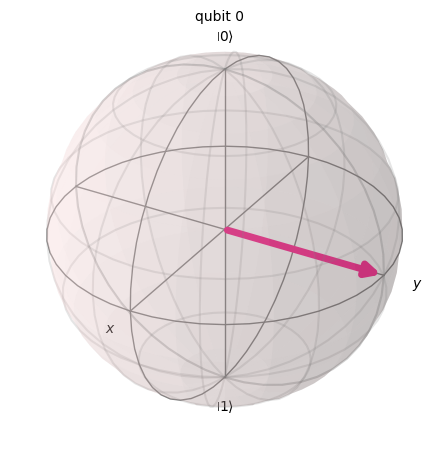

In [12]:
# TODO: Create these states from amplitudes and visualize
ket_i = Statevector([1/np.sqrt(2), 1j/np.sqrt(2)])
ket_minus_i = Statevector([1/np.sqrt(2), -1j/np.sqrt(2)])  # TODO: Statevector([...])

print("|i⟩ (should be on +Y axis):")
display(plot_bloch_multivector(ket_i))

# TODO: Visualize |-i⟩
# print("|-i⟩ (should be on -Y axis):")
# display(plot_bloch_multivector(ket_minus_i))


 ### Exercise 3.2 (5 points)

 Create states at specific Bloch sphere coordinates.

 General state: $|\psi\rangle = \cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle$

a) θ=π/3, φ=0:


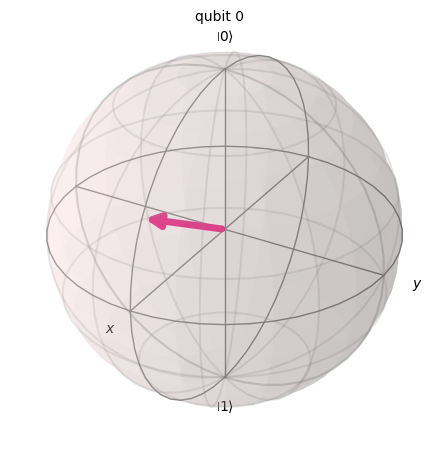

b) θ=π/2, φ=3π/4:


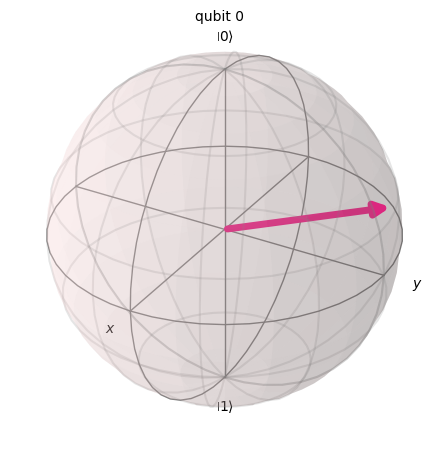

c) θ=3π/4, φ=π/2:


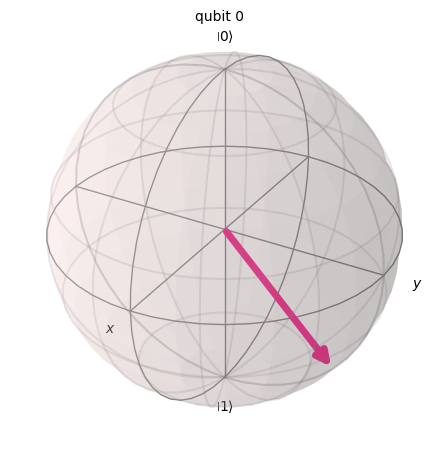

d) θ=π/6, φ=π:


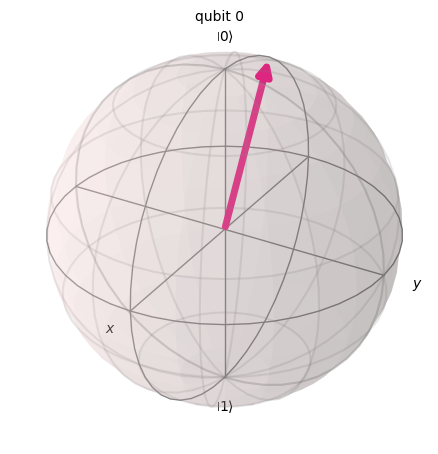

In [13]:
def create_state(theta, phi):
    """Create qubit state from Bloch sphere angles θ, φ."""
    alpha = np.cos(theta / 2)
    beta = np.exp(1j * phi) * np.sin(theta / 2)
    return Statevector([alpha, beta])

# TODO: Create and visualize states at these coordinates (different from lecture):
# a) θ = π/3, φ = 0 (tilted toward +X)
# b) θ = π/2, φ = 3π/4 (on equator, between -X and +Y)
# c) θ = 3π/4, φ = π/2 (tilted toward south, on +Y side)
# d) θ = π/6, φ = π (near north pole, on -X side)

# Example for (a):
state_a = create_state(np.pi/3, 0)
print("a) θ=π/3, φ=0:")
display(plot_bloch_multivector(state_a))

# TODO: Create and visualize states (b), (c), (d)
# b) θ = π/2, φ = 3π/4
state_b = create_state(np.pi/2, 3*np.pi/4)
print("b) θ=π/2, φ=3π/4:")
display(plot_bloch_multivector(state_b))

# c) θ = 3π/4, φ = π/2
state_c = create_state(3*np.pi/4, np.pi/2)
print("c) θ=3π/4, φ=π/2:")
display(plot_bloch_multivector(state_c))

# d) θ = π/6, φ = π
state_d = create_state(np.pi/6, np.pi)
print("d) θ=π/6, φ=π:")
display(plot_bloch_multivector(state_d))


 ### Exercise 3.3 (5 points)

 Convert state amplitudes to Bloch coordinates.

In [14]:
def amplitudes_to_bloch(alpha, beta):
    """Convert amplitudes to Bloch vector (x, y, z)."""
    x = 2 * np.real(np.conj(alpha) * beta)
    y = 2 * np.imag(np.conj(alpha) * beta)
    z = np.abs(alpha)**2 - np.abs(beta)**2
    return (x, y, z)

# TODO: Calculate Bloch coordinates for these states (different from lecture):
# a) |i⟩ = (|0⟩ + i|1⟩)/√2 (should be (0, 1, 0))
# b) |-i⟩ = (|0⟩ - i|1⟩)/√2 (should be (0, -1, 0))
# c) (1/2)|0⟩ + (√3/2)|1⟩ (what are the coordinates?)
# d) (1/√2)|0⟩ + (i/√2)|1⟩ (same as |i⟩, verify!)
# e) (1/√2)|0⟩ + (e^(iπ/4)/√2)|1⟩ (where does this land?)

print("a) |i⟩ coords:", amplitudes_to_bloch(1/np.sqrt(2), 1j/np.sqrt(2)))
print("b) |-i⟩ coords:", amplitudes_to_bloch(1/np.sqrt(2), -1j/np.sqrt(2)))  # TODO
print("c) (1/2)|0⟩ + (√3/2)|1⟩ coords:", amplitudes_to_bloch(1/2, np.sqrt(3)/2))  # TODO
print("d) verify |i⟩:", amplitudes_to_bloch(1/np.sqrt(2), 1j/np.sqrt(2)))  # TODO
print("e) state with e^(iπ/4) phase:", amplitudes_to_bloch(1/np.sqrt(2), np.exp(1j*np.pi/4)/np.sqrt(2)))  # TODO


a) |i⟩ coords: (np.float64(0.0), np.float64(0.9999999999999998), np.float64(0.0))
b) |-i⟩ coords: (np.float64(0.0), np.float64(-0.9999999999999998), np.float64(0.0))
c) (1/2)|0⟩ + (√3/2)|1⟩ coords: (np.float64(0.8660254037844386), np.float64(0.0), np.float64(-0.4999999999999999))
d) verify |i⟩: (np.float64(0.0), np.float64(0.9999999999999998), np.float64(0.0))
e) state with e^(iπ/4) phase: (np.float64(0.7071067811865475), np.float64(0.7071067811865475), np.float64(-2.220446049250313e-16))


 ### Exercise 3.4 (5 points)

 Given a state, predict and verify measurement probabilities.

In [15]:
# State: |ψ⟩ = (√3/2)|0⟩ + (1/2)|1⟩
psi = Statevector([np.sqrt(3)/2, 1/2])

# TODO: Calculate P(0) and P(1) using the formula |amplitude|²
P_0_theory = np.abs(np.sqrt(3)/2)**2  # TODO: |√3/2|²
P_1_theory = np.abs(1/2)**2  # TODO: |1/2|²

print(f"Theoretical P(0) = {P_0_theory}")
print(f"Theoretical P(1) = {P_1_theory}")

# Verify with Qiskit's probabilities
print(f"Qiskit P(0), P(1) = {psi.probabilities()}")


Theoretical P(0) = 0.7499999999999999
Theoretical P(1) = 0.25
Qiskit P(0), P(1) = [0.75 0.25]


 ### Exercise 3.5 (5 points)

 Measurement in different bases.

 To measure in X-basis, apply H first, then measure in Z-basis.

In [16]:
# Create |+⟩ state
qc = QuantumCircuit(1)
qc.h(0)
plus_state = Statevector(qc)

# If we measure |+⟩ in Z-basis, we get 50/50
print(f"|+⟩ measured in Z-basis: P(0)={plus_state.probabilities()[0]:.3f}, P(1)={plus_state.probabilities()[1]:.3f}")

# TODO: What if we measure |+⟩ in X-basis?
# Apply H to |+⟩ (giving |0⟩), then check probabilities
# What are P(+) and P(-)?

qc2 = QuantumCircuit(1) # qc2 = QuantumCircuit(1)
qc2.h(0) # qc2.h(0)  # Creates |+⟩
qc2.h(0) # qc2.h(0)  # Rotate to measure in X-basis
# state_for_x_measurement = Statevector(qc2)
# P_plus = ...
# P_minus = ...
state_for_x_measurement = Statevector(qc2)
P_plus = state_for_x_measurement.probabilities()[0]
P_minus = state_for_x_measurement.probabilities()[1]
print(f"|+⟩ measured in X-basis: P(+)={P_plus:.3f}, P(-)={P_minus:.3f}")

|+⟩ measured in Z-basis: P(0)=0.500, P(1)=0.500
|+⟩ measured in X-basis: P(+)=1.000, P(-)=0.000


 ---

 ## Part 4: Gates as Rotations (30 points)

 ### Exercise 4.1 (6 points)

 Verify Pauli gate properties: anti-commutation.



 We know $X^2 = Y^2 = Z^2 = I$. Now explore how Pauli gates interact.

 Anti-commutation: $XZ = -ZX$ (and similar for other pairs)

ZX|+⟩:


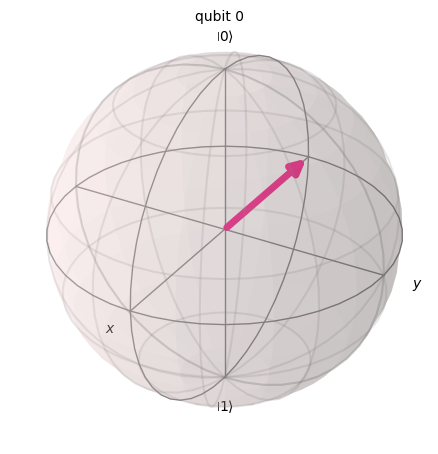

ZX|+⟩:


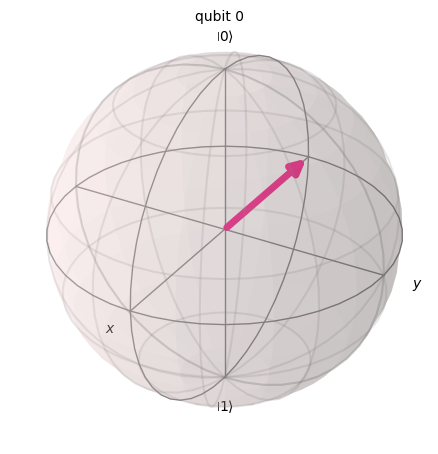

XZ|0⟩ = [ 0.+0.j -1.+0.j]
ZX|0⟩ = [0.+0.j 1.+0.j]
-ZX|0⟩ = [-0.-0.j -1.-0.j]
XYX|0⟩ = [0.+0.j 0.-1.j]
-Y|0⟩ = [-0.-0.j -0.-1.j]


In [17]:
# a) Apply X then Z to |+⟩, visualize
qc_xz = QuantumCircuit(1)
qc_xz.h(0)  # Create |+⟩
qc_xz.x(0)
qc_xz.z(0)
state_xz = Statevector(qc_xz)
print("ZX|+⟩:")
display(plot_bloch_multivector(state_xz))

# b) TODO: Apply Z then X to |+⟩, visualize
# Compare to (a) — they should differ by a global phase (look the same on Bloch sphere
# but have opposite signs in the state vector)
qc_zx = QuantumCircuit(1)
qc_zx.h(0)  
qc_zx.z(0)
qc_zx.x(0)
state_zx = Statevector(qc_zx)
print("ZX|+⟩:")
display(plot_bloch_multivector(state_zx))

# c) TODO: Verify XZ|0⟩ = -ZX|0⟩ by comparing state vectors
# Use Statevector.data to see the actual amplitudes
qc_xz0 = QuantumCircuit(1)
qc_xz0.x(0)
qc_xz0.z(0)
state_xz0 = Statevector(qc_xz0)
qc_zx0 = QuantumCircuit(1)
qc_zx0.z(0)
qc_zx0.x(0)
state_zx0 = Statevector(qc_zx0)

print(f"XZ|0⟩ = {state_xz0.data}")
print(f"ZX|0⟩ = {state_zx0.data}")
print(f"-ZX|0⟩ = {-state_zx0.data}")

# d) TODO: What is XYX? Apply to |0⟩ and compare to applying -Y|0⟩
# Hint: Use the relation XY = iZ and similar identities

qc_xyx = QuantumCircuit(1)
qc_xyx.x(0)
qc_xyx.y(0)
qc_xyx.x(0)
state_xyx = Statevector(qc_xyx)
print(f"XYX|0⟩ = {state_xyx.data}")

qc_y = QuantumCircuit(1)
qc_y.y(0)
state_y = Statevector(qc_y)
print(f"-Y|0⟩ = {-state_y.data}")


 ### Exercise 4.2 (6 points)

 The Hadamard gate as a basis change: explore H applied to Y-basis states.



 We know H swaps Z and X bases:

 $H|0\rangle = |+\rangle$, $H|1\rangle = |-\rangle$, $H|+\rangle = |0\rangle$, $H|-\rangle = |1\rangle$



 What does H do to the Y-basis states $|i\rangle$ and $|-i\rangle$?

H|i⟩:


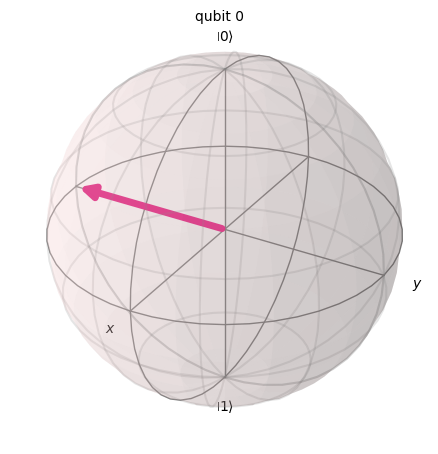

H|-i⟩:


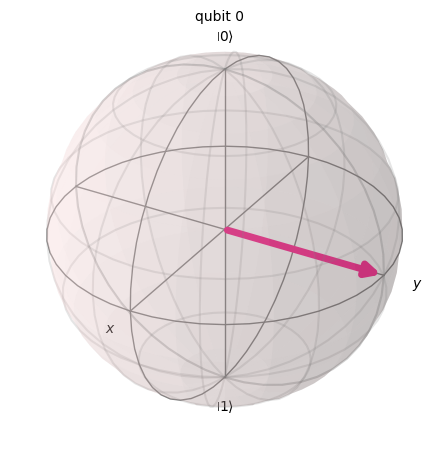

HH|i⟩:


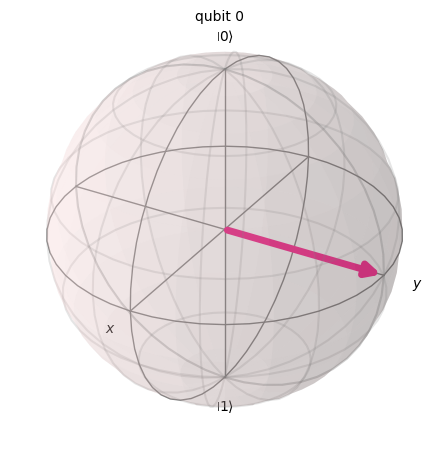

HYH|0⟩ = [0.+0.j 0.-1.j]


In [18]:
# a) Create |i⟩, apply H, visualize. Where does it land?
qc_i = QuantumCircuit(1)
qc_i.initialize([1/np.sqrt(2), 1j/np.sqrt(2)], 0)
qc_i.h(0)
state_H_i = Statevector(qc_i)
print("H|i⟩:")
display(plot_bloch_multivector(state_H_i))

# b) TODO: Create |-i⟩, apply H, visualize. Where does it land?
qc_minus_i = QuantumCircuit(1)
qc_minus_i.initialize([1/np.sqrt(2), -1j/np.sqrt(2)], 0)
qc_minus_i.h(0)
state_H_minus_i = Statevector(qc_minus_i)
print("H|-i⟩:")
display(plot_bloch_multivector(state_H_minus_i))
# c) TODO: Apply H twice to |i⟩. What do you get? (Should return to |i⟩)
qc_hh = QuantumCircuit(1)
qc_hh.initialize([1/np.sqrt(2), 1j/np.sqrt(2)], 0)
qc_hh.h(0)
qc_hh.h(0)
state_HH_i = Statevector(qc_hh)
print("HH|i⟩:")
display(plot_bloch_multivector(state_HH_i))
# d) TODO: What is HYH? Apply Y to |0⟩, then H, and compare to applying HYH directly
# Hint: HXH = Z, HZH = X. What about Y?
qc_hyh = QuantumCircuit(1)
qc_hyh.h(0)
qc_hyh.y(0)
qc_hyh.h(0)
state_HYH = Statevector(qc_hyh)
print(f"HYH|0⟩ = {state_HYH.data}")

 ### Exercise 4.3 (6 points)

 Z gate adds phase without changing Z-basis probabilities.

Z|+⟩:
Probabilities: [0.5 0.5]


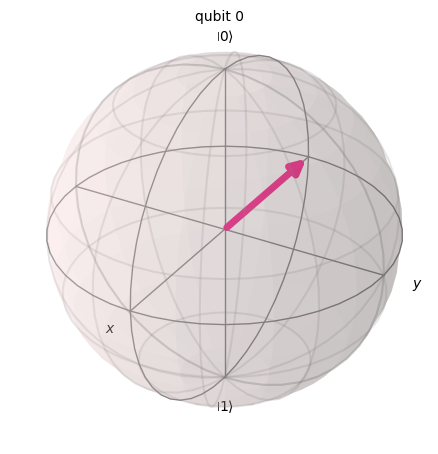

Z|0⟩:


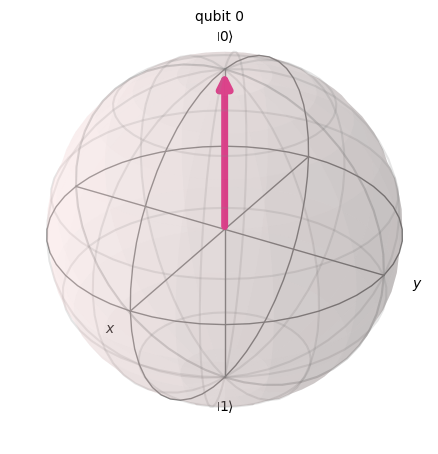

Z|1⟩:


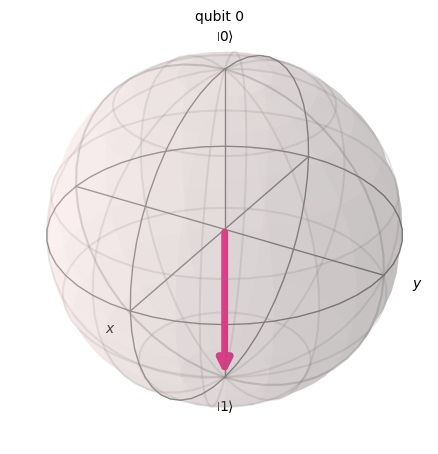

Z|i⟩:


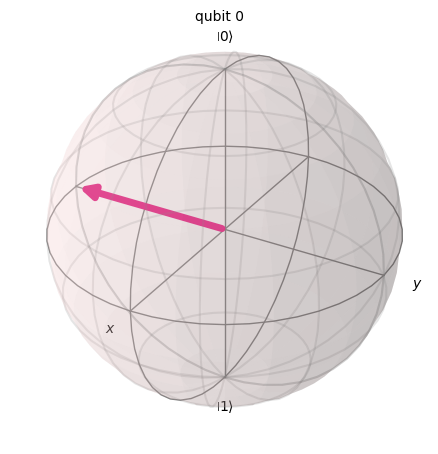

In [19]:
# Apply Z to |+⟩
qc = QuantumCircuit(1)
qc.h(0)  # |+⟩
qc.z(0)  # Z|+⟩ = |-⟩

state_after_z = Statevector(qc)
print("Z|+⟩:")
print(f"Probabilities: {state_after_z.probabilities()}")  # Still 50/50!
display(plot_bloch_multivector(state_after_z))

# TODO: Apply Z to |0⟩ and |1⟩. What changes? What stays the same?
# TODO: Apply Z to |i⟩. Where does it end up on the Bloch sphere?
qc_z0 = QuantumCircuit(1)
qc_z0.z(0)
state_z0 = Statevector(qc_z0)
print("Z|0⟩:")
display(plot_bloch_multivector(state_z0))

qc_z1 = QuantumCircuit(1)
qc_z1.x(0)  # Create |1⟩
qc_z1.z(0)
state_z1 = Statevector(qc_z1)
print("Z|1⟩:")
display(plot_bloch_multivector(state_z1))

# Apply Z to |i⟩
qc_zi = QuantumCircuit(1)
qc_zi.initialize([1/np.sqrt(2), 1j/np.sqrt(2)], 0)
qc_zi.z(0)
state_zi = Statevector(qc_zi)
print("Z|i⟩:")
display(plot_bloch_multivector(state_zi))

 ### Exercise 4.4 (6 points)

 Explore rotation gates $R_x$, $R_y$, $R_z$ with specific angles.

a) Ry(2π/3)|0⟩:


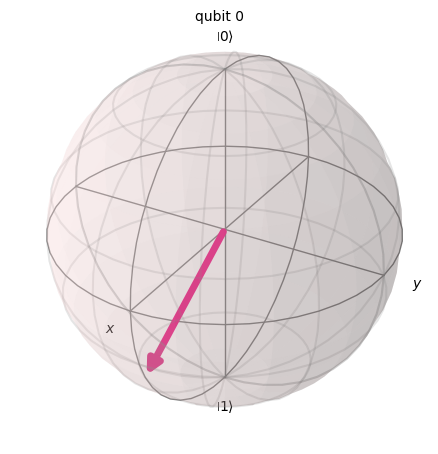

b) Rx(π)|+⟩:


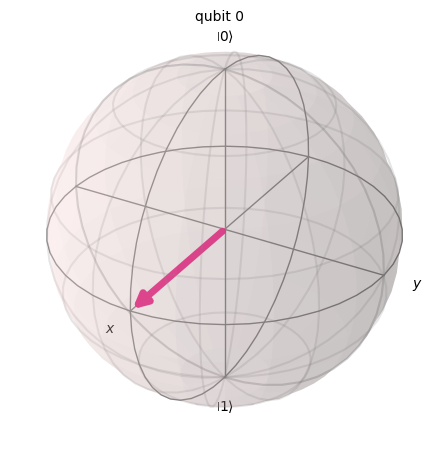

c) Rz(π/2)|+⟩:


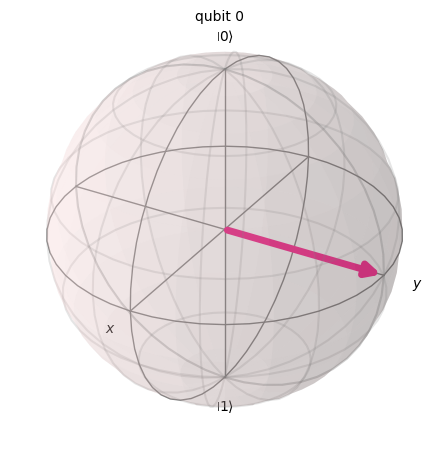

d) Rz(π/2) after Ry(π/2)|0⟩:


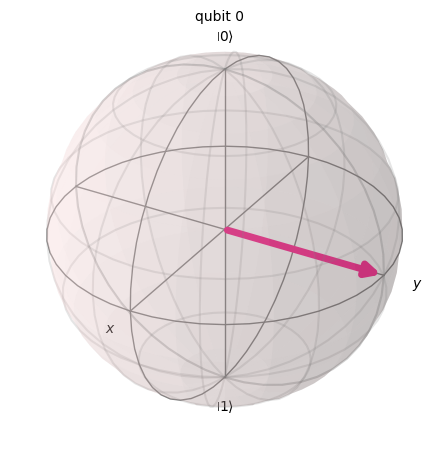

e) Ry(π/2) after Rz(π/2)|0⟩:


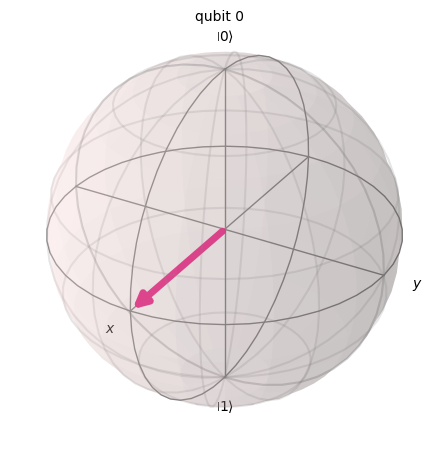

In [20]:
from qiskit.circuit.library import RXGate, RYGate, RZGate

# TODO: Answer these questions by creating circuits and visualizing:

# a) What is Ry(2π/3)|0⟩? Visualize and give Bloch coordinates.
qc_a = QuantumCircuit(1)
qc_a.ry(2*np.pi/3, 0)
state_a = Statevector(qc_a)
print("a) Ry(2π/3)|0⟩:")
display(plot_bloch_multivector(state_a))

# b) What is Rx(π)|+⟩? Where does it land?
# Hint: |+⟩ is on the X-axis, rotating around X should keep it there

# c) What is Rz(π/2)|+⟩? This should give |i⟩
# Verify by comparing Bloch coordinates

# d) Combine rotations: Apply Ry(π/2) then Rz(π/2) to |0⟩
# Where do you end up? Visualize.

# e) Does order matter? Apply Rz(π/2) then Ry(π/2) to |0⟩

# Compare to part (d)

qc_b = QuantumCircuit(1)
qc_b.h(0)  # Create |+⟩
qc_b.rx(np.pi, 0)
state_b = Statevector(qc_b)
print("b) Rx(π)|+⟩:")
display(plot_bloch_multivector(state_b))

# c) What is Rz(π/2)|+⟩?
qc_c = QuantumCircuit(1)
qc_c.h(0)  # Create |+⟩
qc_c.rz(np.pi/2, 0)
state_c = Statevector(qc_c)
print("c) Rz(π/2)|+⟩:")
display(plot_bloch_multivector(state_c))

# d) Apply Ry(π/2) then Rz(π/2) to |0⟩
qc_d = QuantumCircuit(1)
qc_d.ry(np.pi/2, 0)
qc_d.rz(np.pi/2, 0)
state_d = Statevector(qc_d)
print("d) Rz(π/2) after Ry(π/2)|0⟩:")
display(plot_bloch_multivector(state_d))

# e) Apply Rz(π/2) then Ry(π/2) to |0⟩
qc_e = QuantumCircuit(1)
qc_e.rz(np.pi/2, 0)
qc_e.ry(np.pi/2, 0)
state_e = Statevector(qc_e)
print("e) Ry(π/2) after Rz(π/2)|0⟩:")
display(plot_bloch_multivector(state_e))

 ### Exercise 4.5 (6 points)

 Create a specific target state using only rotation gates.



 **Target:** The state at $\theta=2\pi/3$, $\phi=5\pi/6$ on the Bloch sphere.



 **Method:** Start from $|0\rangle$, apply $R_y(\theta)$ to tilt from north pole, then $R_z(\phi)$ for phase.

State created via gates:


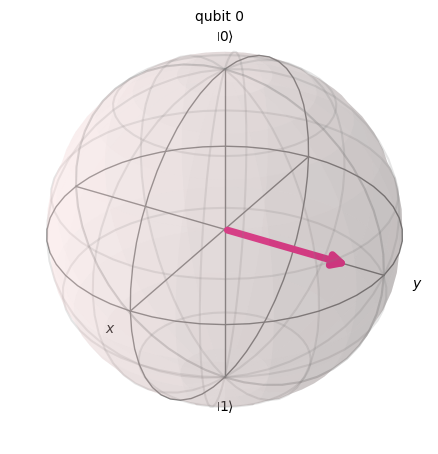

State created directly:


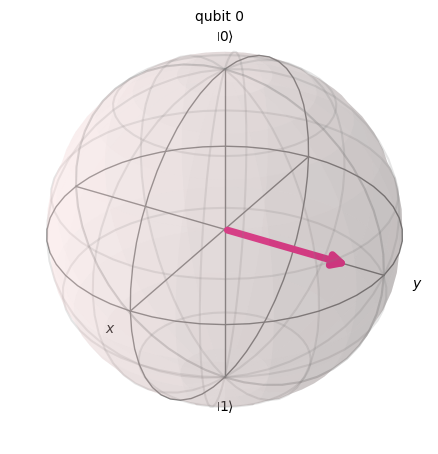

Bloch coords (gates): (np.float64(-0.7500000000000001), np.float64(0.4330127018922194), np.float64(-0.49999999999999956))
Bloch coords (direct): (np.float64(-0.7500000000000002), np.float64(0.43301270189221935), np.float64(-0.4999999999999998))
Match: True


In [21]:
target_theta = 2 * np.pi / 3
target_phi = 5 * np.pi / 6

# Method: Start from |0⟩, apply Ry(θ) to tilt from north pole, then Rz(φ) for phase

qc = QuantumCircuit(1)
# TODO: Apply appropriate gates to reach the target state
# qc.ry(???, 0)
# qc.rz(???, 0)
qc.ry(target_theta, 0)
qc.rz(target_phi, 0)

state_via_gates = Statevector(qc)
print("State created via gates:")
display(plot_bloch_multivector(state_via_gates))

# Compare with direct creation
state_direct = create_state(target_theta, target_phi)
print("State created directly:")
display(plot_bloch_multivector(state_direct))

# TODO: Verify the states match by comparing Bloch coordinates or amplitudes
# Note: They may differ by a global phase — use amplitudes_to_bloch to compare
bloch_gates = amplitudes_to_bloch(*state_via_gates.data)
bloch_direct = amplitudes_to_bloch(*state_direct.data)
print(f"Bloch coords (gates): {bloch_gates}")
print(f"Bloch coords (direct): {bloch_direct}")
print(f"Match: {np.allclose(bloch_gates, bloch_direct)}")

 ---

 ## Bonus: Challenge Problem (10 extra points)



 The T gate is $R_z(\pi/4)$. Using only H and T gates (and their adjoints),

 create a state that is approximately at $\theta=\pi/4$, $\phi=0$ on the Bloch sphere.



 **Hint:** H-T-H sequences create interesting rotations.

 **Note:** You won't get exactly $\theta=\pi/4$, but try to get close!

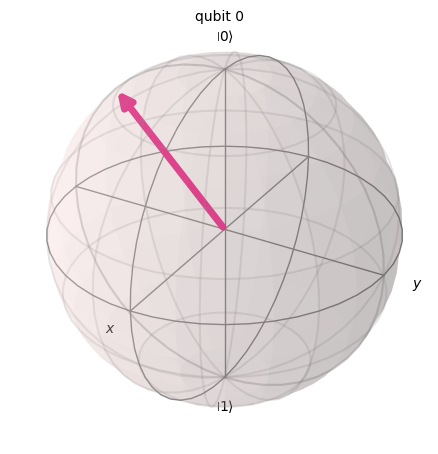

Challenge state Bloch coords: (np.float64(0.0), np.float64(-0.7071067811865471), np.float64(0.7071067811865471))


In [22]:
# qc_challenge = QuantumCircuit(1)
# TODO: Your gate sequence here
# 
# state_challenge = Statevector(qc_challenge)
# print("Challenge state Bloch coords:", amplitudes_to_bloch(*state_challenge.data))
qc_challenge = QuantumCircuit(1)
qc_challenge.h(0)
qc_challenge.t(0)
qc_challenge.h(0)


state_challenge = Statevector(qc_challenge)

display(plot_bloch_multivector(state_challenge))
print("Challenge state Bloch coords:", amplitudes_to_bloch(*state_challenge.data))

 ---

 ## Submission Checklist



 Before submitting, verify:



 - [ ] Part 1: All Dirac notation exercises completed

 - [ ] Part 2: Tensor product states created and verified

 - [ ] Part 3: Bloch sphere visualizations included

 - [ ] Part 4: Gate rotation experiments completed

 - [ ] All TODO items replaced with your code

 - [ ] All cells executed with visible outputs

 - [ ] Visualizations are displayed (not just code)

 - [ ] File saved as .ipynb format



 **Submit to:** Canvas